# PeMS 传感器变化追踪 (2025年)

追踪每次元数据更新时传感器的新增、减少和总数变化。

In [1]:
import pandas as pd
import glob
import os
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# 配置
META_FOLDER = "../d03_meta"  # 修改为你的路径
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_DATE = datetime(2024, 11, 1)
END_DATE = datetime(2025, 12, 31)

In [3]:
def parse_date(filename):
    """从文件名解析日期"""
    match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(filename))
    if match:
        return datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
    return None

def load_sensor_ids(file_path):
    """加载传感器ID集合"""
    df = pd.read_csv(file_path, sep='\t', usecols=[0], dtype=str)
    return set(df.iloc[:, 0].dropna())

# 获取2025年文件
all_files = sorted(glob.glob(os.path.join(META_FOLDER, "d*_text_meta_*.txt")))
files_2025 = [(f, parse_date(f)) for f in all_files if parse_date(f) and START_DATE <= parse_date(f) <= END_DATE]
files_2025.sort(key=lambda x: x[1])

print(f"2025年元数据文件数: {len(files_2025)}")

2025年元数据文件数: 36


In [4]:
# 追踪变化
changes = []
prev_ids = None

for file_path, date in files_2025:
    curr_ids = load_sensor_ids(file_path)
    
    if prev_ids is None:
        added, removed = len(curr_ids), 0
    else:
        added = len(curr_ids - prev_ids)
        removed = len(prev_ids - curr_ids)
    
    changes.append({
        'Date': date,
        'Total': len(curr_ids),
        'Added': added,
        'Removed': removed,
        'Net_Change': added - removed
    })
    
    prev_ids = curr_ids

df = pd.DataFrame(changes)
print(f"\n追踪完成！共 {len(df)} 次更新")


追踪完成！共 36 次更新


In [5]:
# 显示结果
print("传感器变化记录:")
display(df)

传感器变化记录:


,Date,Total,Added,Removed,Net_Change
0,2024-11-27,1859,1859,0,1859
1,2025-01-18,1873,14,0,14
2,2025-01-30,1874,1,0,1
3,2025-02-04,1876,2,0,2
4,2025-02-06,1886,12,2,10
5,2025-02-08,1887,1,0,1
6,2025-02-13,1889,2,0,2
7,2025-03-01,1888,0,1,-1
8,2025-03-18,1888,0,0,0
9,2025-04-08,1888,0,0,0


In [6]:
# 统计摘要
print("=" * 50)
print("统计摘要")
print("=" * 50)
print(f"初始传感器数: {df.iloc[0]['Total']}")
print(f"最终传感器数: {df.iloc[-1]['Total']}")
print(f"总新增: {df['Added'].sum() - df.iloc[0]['Added']}")
print(f"总移除: {df['Removed'].sum()}")
print(f"净变化: {df.iloc[-1]['Total'] - df.iloc[0]['Total']}")

统计摘要
初始传感器数: 1859
最终传感器数: 1903
总新增: 85
总移除: 41
净变化: 44


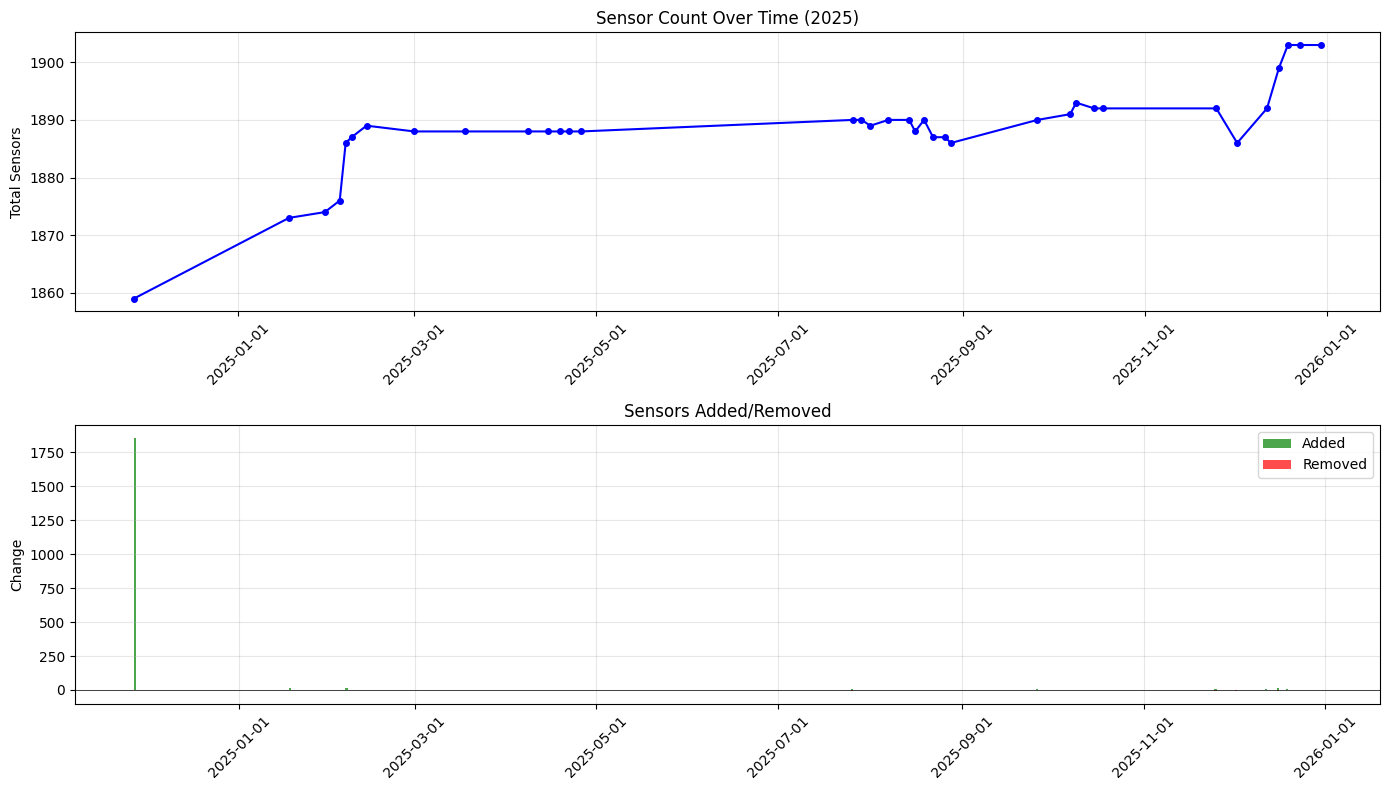

In [7]:
# 可视化
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 总数变化
axes[0].plot(df['Date'], df['Total'], 'b-o', markersize=4)
axes[0].set_ylabel('Total Sensors')
axes[0].set_title('Sensor Count Over Time (2025)')
axes[0].grid(True, alpha=0.3)

# 新增/移除
axes[1].bar(df['Date'], df['Added'], color='green', alpha=0.7, label='Added')
axes[1].bar(df['Date'], -df['Removed'], color='red', alpha=0.7, label='Removed')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_ylabel('Change')
axes[1].set_title('Sensors Added/Removed')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sensor_changes_2025.png'), dpi=150)
plt.show()

In [8]:
# 保存
output_path = os.path.join(OUTPUT_DIR, 'sensor_changes_2025.csv')
df.to_csv(output_path, index=False)
print(f"已保存: {output_path}")

已保存: ../output/sensor_changes_2025.csv
